# 🌙 Extracción de Características para Clasificación de Fases — CAP Sleep Database

**Notebook 1 del pipeline reorientado.** Se ejecuta **después** de
`Reetiquetado_Hipnograma.ipynb` (notebook 0).

### Qué hace

Para cada época de 30 s del hipnograma:

1. Localiza el tramo de señal en el EDF usando `edf_start_sample`.
2. Lo extrae y, si la frecuencia nativa difiere, lo **resamplea a 256 Hz**
   (→ 7680 muestras).
3. Calcula ~30 características (tiempo, frecuencia, Hjorth, entropía),
   reutilizando las funciones del pipeline original adaptadas a 30 s.
4. Asigna la etiqueta de **fase de sueño R&K** de esa época.

### Diferencia con el notebook de extracción original

| Original (incorrecto) | Ahora (correcto) |
|-----------------------|------------------|
| Ventana de 3 s | Época de **30 s** (estándar de estadificación) |
| Etiqueta = diagnóstico del paciente | Etiqueta = **fase de sueño real** |
| Bandas EEG genéricas | Bandas adaptadas a sueño (incluye **sigma** para husos) |

### Bandas EEG para sueño

Se añade la banda **sigma (11–16 Hz)**, ausente en el pipeline original,
porque los **husos del sueño** (sleep spindles) son el marcador
electrofisiológico distintivo de la fase S2. Sin ella, S2 sería difícil de
separar de S1.

## 1. Importaciones y configuración

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import signal as scipy_signal
from scipy import stats as scipy_stats

import mne

warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')

plt.rcParams.update({
    'figure.dpi': 110, 'figure.figsize': (13, 5),
    'axes.titlesize': 13, 'axes.labelsize': 11, 'font.size': 10,
})
sns.set_style('whitegrid')

# Compatibilidad NumPy 2.x: trapezoid reemplaza a trapz
_trapz = getattr(np, 'trapezoid', None) or np.trapz

# ── Rutas ──
UPLOADS_DIR = Path('../cap-sleep-database/')          # .txt y .edf
HYPNO_DIR      = Path.cwd() / '../data/hypnograms'          # salida notebook 0
FEATURES_DIR   = Path.cwd() / '../data/features_fases'
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
EDF_DIR        = UPLOADS_DIR                                # carpeta con .edf

# ── Parámetros ──
TARGET_FS      = 256                      # Hz, frecuencia común
EPOCH_SECONDS  = 30                       # duración de época (estándar)
EPOCH_SAMPLES  = TARGET_FS * EPOCH_SECONDS  # 7680 muestras

# Nº de canales EEG a procesar por paciente.
#   - Para estadificación basta 1-2 derivaciones centrales (C4-A1 es la
#     recomendada por AASM). Procesar todos los canales multiplica el tiempo
#     y aporta informacion redundante.
#   - Pon MAX_CANALES = None para usar TODOS los canales EEG.
# Tiempo orientativo: ~3 s por paciente y por canal (EDF de ~250 MB).
MAX_CANALES    = 2

CLASES_RK = ['W', 'S1', 'S2', 'S3', 'S4', 'REM']

# Bandas EEG adaptadas a sueño (incluye SIGMA para husos de S2)
EEG_BANDS = {
    'delta': (0.5, 4.0),
    'theta': (4.0, 8.0),
    'alpha': (8.0, 11.0),
    'sigma': (11.0, 16.0),   # husos del sueño — clave para S2
    'beta':  (16.0, 30.0),
}

print(f'Frecuencia objetivo : {TARGET_FS} Hz')
print(f'Época               : {EPOCH_SECONDS} s = {EPOCH_SAMPLES} muestras')
print(f'Clases R&K          : {CLASES_RK}')
print(f'Bandas EEG          : {list(EEG_BANDS.keys())}')

Frecuencia objetivo : 256 Hz
Época               : 30 s = 7680 muestras
Clases R&K          : ['W', 'S1', 'S2', 'S3', 'S4', 'REM']
Bandas EEG          : ['delta', 'theta', 'alpha', 'sigma', 'beta']


## 2. Identificación de canales EEG

Los EDF de la CAP DB contienen señales mixtas (EEG, EMG, ECG, respiratorias,
SpO₂…). Para clasificación de fases usamos solo **canales EEG**: derivaciones
bipolares del sistema 10-20. La función `es_canal_eeg` los identifica y
descarta explícitamente los no-EEG.

> **Canal de referencia común:** `C4-A1` es una derivación central estándar
> AASM presente en ambos EDF de ejemplo. Las derivaciones centrales son las
> mejores para estadificación porque capturan husos (S2), complejos K y
> ondas lentas (S3/S4).

In [2]:
# Conjuntos de electrodos 10-20 reconocidos
_ELECTRODOS_EEG = {'FP1','FP2','F3','F4','F7','F8','FZ','C3','C4','CZ',
                   'P3','P4','PZ','O1','O2','T3','T4','T5','T6','A1','A2'}
_NO_EEG_TOKENS = {'EMG','ECG','EKG','SAO2','SPO2','MIC','FLUSSO','FLOW',
                  'TORACE','ADDOME','ADDDOME','POSITION','HR','PLETH','STAT',
                  'ROC','LOC'}

def es_canal_eeg(nombre):
    '''True si el canal es una derivación EEG 10-20 (no EMG/ECG/resp/etc.).'''
    u = nombre.upper()
    if any(tok in u for tok in _NO_EEG_TOKENS):
        return False
    # Separar por guion y comprobar que los componentes son electrodos 10-20
    partes = u.replace(' ', '').split('-')
    return any(p in _ELECTRODOS_EEG for p in partes)


def listar_canales_eeg(raw):
    return [c for c in raw.ch_names if es_canal_eeg(c)]


# Demostración con los EDF disponibles
for edf in sorted(EDF_DIR.glob('*.edf')):
    raw = mne.io.read_raw_edf(edf, preload=False, verbose='ERROR')
    eeg = listar_canales_eeg(raw)
    print(f'{edf.name}: fs={raw.info["sfreq"]:.0f} Hz | '
          f'{len(eeg)} canales EEG: {eeg}')

brux1.edf: fs=512 Hz | 13 canales EEG: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'F8-T4', 'T4-T6', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'F7-T3', 'T3-T5', 'C4-A1']
brux2.edf: fs=256 Hz | 13 canales EEG: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'F8-T4', 'T4-T6', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'F7-T3', 'T3-T5', 'C4-A1']
ins1.edf: fs=256 Hz | 5 canales EEG: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'C4-A1']
ins2.edf: fs=512 Hz | 5 canales EEG: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'C4-A1']
ins3.edf: fs=256 Hz | 7 canales EEG: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'C4-A1', 'F8-T4', 'F7-T3']
ins4.edf: fs=512 Hz | 5 canales EEG: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'C4-A1']
ins5.edf: fs=512 Hz | 5 canales EEG: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'C4-A1']
ins6.edf: fs=512 Hz | 5 canales EEG: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'C4-A1']
ins7.edf: fs=512 Hz | 5 canales EEG: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'C4-A1']
ins8.edf: fs=512 Hz | 11 canales EEG: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 

## 3. Funciones de extracción de características

Reutilizamos las cuatro familias del pipeline original (tiempo, frecuencia,
Hjorth, entropía), con dos cambios para sueño:

- Ventana de **7680 muestras** (30 s) en lugar de 768 (3 s).
- Banda **sigma** añadida en el dominio frecuencial.

El cálculo es idéntico al notebook de extracción original ya validado.

In [3]:
def extract_time_features(ventana):
    '''12 características estadísticas en el dominio del tiempo.'''
    x = np.asarray(ventana, dtype=float).ravel()
    if x.size == 0 or np.all(np.isnan(x)):
        return {k: np.nan for k in ('media','mediana','std','varianza','rms',
                'energia','maximo','minimo','rango','skewness','kurtosis','zcr')}
    std = np.std(x)
    return {
        'media': np.mean(x), 'mediana': np.median(x), 'std': std,
        'varianza': np.var(x), 'rms': np.sqrt(np.mean(x**2)),
        'energia': np.sum(x**2), 'maximo': np.max(x), 'minimo': np.min(x),
        'rango': np.ptp(x),
        'skewness': scipy_stats.skew(x) if std > 0 else 0.0,
        'kurtosis': scipy_stats.kurtosis(x) if std > 0 else 0.0,
        'zcr': np.mean(np.diff(np.sign(x)) != 0),
    }


def extract_frequency_features(ventana, sfreq=TARGET_FS, bandas=EEG_BANDS):
    '''Características espectrales por banda EEG vía Welch PSD.'''
    x = np.asarray(ventana, dtype=float).ravel()
    nperseg = min(int(sfreq * 2), len(x))   # ventanas de 2 s para Welch
    f, psd = scipy_signal.welch(x, fs=sfreq, nperseg=nperseg,
                                 noverlap=nperseg // 2, scaling='density')
    pot_total = _trapz(psd, f)
    feats = {'pot_total': pot_total}
    for nombre, (lo, hi) in bandas.items():
        m = (f >= lo) & (f < hi)
        pa = _trapz(psd[m], f[m]) if m.any() else 0.0
        feats[f'pot_{nombre}'] = pa
        feats[f'pot_{nombre}_rel'] = pa / pot_total if pot_total > 0 else 0.0
    feats['freq_dominante'] = f[np.argmax(psd)] if len(psd) else 0.0
    if pot_total > 0:
        df = f[1] - f[0] if len(f) > 1 else 1.0
        cum = np.cumsum(psd) * df
        feats['freq_mediana'] = f[min(np.searchsorted(cum, pot_total/2), len(f)-1)]
    else:
        feats['freq_mediana'] = 0.0
    # Ratios espectrales útiles para estadificación
    feats['ratio_delta_beta'] = (feats['pot_delta'] / feats['pot_beta']
                                 if feats['pot_beta'] > 0 else 0.0)
    feats['ratio_slow_fast'] = ((feats['pot_delta'] + feats['pot_theta']) /
                                (feats['pot_alpha'] + feats['pot_sigma'] + feats['pot_beta'])
                                if (feats['pot_alpha']+feats['pot_sigma']+feats['pot_beta']) > 0 else 0.0)
    return feats


def extract_hjorth_parameters(ventana):
    '''Activity, Mobility, Complexity de Hjorth.'''
    x = np.asarray(ventana, dtype=float).ravel()
    dx, ddx = np.diff(x), np.diff(np.diff(x))
    vx, vdx, vddx = np.var(x), np.var(dx), np.var(ddx)
    mob = np.sqrt(vdx / vx) if vx > 0 else 0.0
    mob_dx = np.sqrt(vddx / vdx) if vdx > 0 else 0.0
    return {
        'hjorth_activity': vx,
        'hjorth_mobility': mob,
        'hjorth_complexity': mob_dx / mob if mob > 0 else 0.0,
    }


def extract_entropy(ventana, sfreq=TARGET_FS, bins=16):
    '''Entropía de Shannon (amplitudes) y espectral (PSD).'''
    x = np.asarray(ventana, dtype=float).ravel()
    hist, _ = np.histogram(x, bins=bins)
    p = hist[hist > 0] / hist.sum()
    shannon = -np.sum(p * np.log2(p)) if p.size else 0.0
    nperseg = min(int(sfreq * 2), len(x))
    _, psd = scipy_signal.welch(x, fs=sfreq, nperseg=nperseg, noverlap=nperseg//2)
    pn = psd / psd.sum() if psd.sum() > 0 else psd
    pn = pn[pn > 0]
    spectral = -np.sum(pn * np.log2(pn)) if pn.size else 0.0
    return {'entropia_shannon': shannon, 'entropia_espectral': spectral}


def extract_features_from_epoch(ventana, sfreq=TARGET_FS, bandas=EEG_BANDS):
    '''Pipeline maestro: ~35 características por época.'''
    try:
        x = np.asarray(ventana, dtype=float).ravel()
        if x.size == 0 or np.all(np.isnan(x)):
            raise ValueError('época vacía')
        feats = {}
        feats.update(extract_time_features(x))
        feats.update(extract_frequency_features(x, sfreq, bandas))
        feats.update(extract_hjorth_parameters(x))
        feats.update(extract_entropy(x, sfreq))
        return feats
    except Exception:
        # Vector NaN con la forma correcta para no romper el DataFrame
        plantilla = {}
        plantilla.update(extract_time_features(np.zeros(10)))
        plantilla.update(extract_frequency_features(np.zeros(int(sfreq*4)), sfreq, bandas))
        plantilla.update(extract_hjorth_parameters(np.zeros(10)))
        plantilla.update(extract_entropy(np.zeros(int(sfreq*4)), sfreq))
        return {k: np.nan for k in plantilla}


# Prueba rápida con una señal sintética sigma-dominante (simula huso S2)
t = np.arange(EPOCH_SAMPLES) / TARGET_FS
demo = 15*np.sin(2*np.pi*13*t) + 5*np.sin(2*np.pi*1*t) + np.random.randn(EPOCH_SAMPLES)
fd = extract_features_from_epoch(demo)
print(f'Características por época: {len(fd)}')
print(f'  sigma_rel (debería ser alto): {fd["pot_sigma_rel"]:.3f}')
print(f'  freq_dominante: {fd["freq_dominante"]:.1f} Hz')

Características por época: 32
  sigma_rel (debería ser alto): 0.892
  freq_dominante: 13.0 Hz


## 4. Carga del hipnograma y sincronización con EDF

Cargamos el hipnograma consolidado del notebook 0. Si no incluye la columna
`edf_start_sample` (porque se generó sin EDF disponibles), la recalculamos
aquí leyendo cada EDF.

In [4]:
def cargar_hipnograma(patient):
    """Carga el hipnograma de un paciente. Devuelve None si no existe o está vacío."""
    ruta_individual = HYPNO_DIR / f'{patient}_hipnograma.csv'
    cons = HYPNO_DIR / 'hipnogramas_consolidado.csv'

    if ruta_individual.exists():
        df = pd.read_csv(ruta_individual)
    elif cons.exists():
        df_all = pd.read_csv(cons)
        df = df_all[df_all['patient'] == patient].reset_index(drop=True)
    else:
        return None

    # Devolver None si quedó vacío o le falta la columna de sincronización
    if len(df) == 0 or 'time_str' not in df.columns:
        return None
    return df


def sincronizar(patient, hip, edf_dir=EDF_DIR):
    '''Calcula edf_start_sample con la fs NATIVA del EDF (necesario para
    extraer correctamente; el resampleo se hace después de extraer).'''
    edf_path = Path(edf_dir) / f'{patient}.edf'
    if not edf_path.exists():
        return None, None
    raw = mne.io.read_raw_edf(edf_path, preload=False, verbose='ERROR')
    fs = raw.info['sfreq']
    md = raw.info['meas_date']
    edf_clock = md.hour*3600 + md.minute*60 + md.second
    h, m, s = map(int, str(hip['time_str'].iloc[0]).split(':'))
    offset = (h*3600 + m*60 + s) - edf_clock
    if offset < -12*3600: offset += 24*3600
    elif offset > 12*3600: offset -= 24*3600

    hip = hip.copy()
    hip['edf_start_sec'] = offset + hip['onset_s']
    hip['edf_start_sample_native'] = (hip['edf_start_sec'] * fs).round().astype(int)
    fin = hip['edf_start_sample_native'] + int(EPOCH_SECONDS * fs)
    validas = (hip['edf_start_sample_native'] >= 0) & (fin <= raw.n_times)
    hip = hip[validas].reset_index(drop=True)
    return hip, raw


# Descubrir pacientes con EDF disponible
pacientes = sorted({p.stem for p in EDF_DIR.glob('*.edf')})
print(f'Pacientes con EDF: {pacientes}')

Pacientes con EDF: ['brux1', 'brux2', 'ins1', 'ins2', 'ins3', 'ins4', 'ins5', 'ins6', 'ins7', 'ins8', 'ins9', 'n1', 'n10', 'n11', 'n12', 'n13', 'n14', 'n15', 'n16', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9', 'narco1', 'narco2', 'narco3', 'narco4', 'narco5', 'nfle1', 'nfle10', 'nfle11', 'nfle12', 'nfle13', 'nfle14', 'nfle15', 'nfle16', 'nfle17', 'nfle18', 'nfle19', 'nfle2', 'nfle20', 'nfle21', 'nfle22', 'nfle23', 'nfle24', 'nfle25', 'nfle26', 'nfle27', 'nfle28', 'nfle29', 'nfle3', 'nfle30', 'nfle31', 'nfle32', 'nfle33', 'nfle34', 'nfle35', 'nfle36', 'nfle37', 'nfle38', 'nfle39', 'nfle4', 'nfle40', 'nfle5', 'nfle6', 'nfle7', 'nfle8', 'nfle9', 'plm1', 'plm10', 'plm2', 'plm3', 'plm4', 'plm5', 'plm6', 'plm7', 'plm8', 'plm9', 'rbd1', 'rbd10', 'rbd11', 'rbd12', 'rbd13', 'rbd14', 'rbd15', 'rbd16', 'rbd17', 'rbd18', 'rbd19', 'rbd2', 'rbd20', 'rbd21', 'rbd22', 'rbd3', 'rbd4', 'rbd5', 'rbd6', 'rbd7', 'rbd8', 'rbd9', 'sdb1', 'sdb2', 'sdb3', 'sdb4']


## 5. Extracción del dataset completo

Para cada paciente → cada canal EEG → cada época válida:

1. Extraer el tramo `[edf_start_sample_native : +30s]` con la fs nativa.
2. Resamplear a 256 Hz (7680 muestras) si la fs nativa difiere.
3. Calcular las características y asignar la etiqueta de fase.

> **Gestión de memoria:** los EDF se leen con `preload=False` y se accede a
> cada época bajo demanda (`raw[ch, start:stop]`), nunca cargando el archivo
> completo en RAM. Esto permite procesar EDF de cientos de MB.

In [5]:
def extraer_paciente(patient, max_canales=None, verbose=True):
    '''Extrae características de todas las épocas EEG de un paciente.'''
    hip = cargar_hipnograma(patient)
    if hip is None:
        if verbose: print(f'  ⚠️  {patient}: sin hipnograma')
        return pd.DataFrame()
    hip, raw = sincronizar(patient, hip)
    if raw is None:
        if verbose: print(f'  ⚠️  {patient}: sin EDF')
        return pd.DataFrame()
    fs = raw.info['sfreq']
    eeg_chs = listar_canales_eeg(raw)
    if max_canales:
        eeg_chs = eeg_chs[:max_canales]
    n_nativo = int(EPOCH_SECONDS * fs)
    necesita_resampleo = (fs != TARGET_FS)
    filas = []
    for ch in eeg_chs:
        ci = raw.ch_names.index(ch)
        for _, ep in hip.iterrows():
            start = int(ep['edf_start_sample_native'])
            stop = start + n_nativo
            datos, _ = raw[ci, start:stop]
            sig = datos[0]
            if necesita_resampleo:
                sig = scipy_signal.resample(sig, EPOCH_SAMPLES)
            # Convertir a microvoltios (MNE devuelve voltios)
            sig = sig * 1e6
            feats = extract_features_from_epoch(sig)
            fila = {
                'patient': patient, 'channel': ch,
                'epoch_idx': int(ep['epoch_idx']),
                'onset_s': float(ep['onset_s']),
                'stage': ep['stage'],
            }
            fila.update(feats)
            filas.append(fila)
    df = pd.DataFrame(filas)
    if verbose:
        print(f'  {patient}: {len(eeg_chs)} canales × {len(hip)} épocas '
              f'= {len(df)} filas | fs {fs:.0f}→{TARGET_FS} '
              f'{"(resampleado)" if necesita_resampleo else ""}')
    return df
# Extraer todos los pacientes
print('Extrayendo características (puede tardar varios minutos por EDF)...')
dfs = []
for p in pacientes:
    dfs.append(extraer_paciente(p, max_canales=MAX_CANALES))
dataset = pd.concat(dfs, ignore_index=True)
print(f'\n✅ Dataset completo: {dataset.shape[0]:,} filas × {dataset.shape[1]} columnas')

Extrayendo características (puede tardar varios minutos por EDF)...
  ⚠️  brux1: sin hipnograma
  brux2: 2 canales × 1029 épocas = 2058 filas | fs 256→256 
  ins1: 2 canales × 906 épocas = 1812 filas | fs 256→256 
  ins2: 2 canales × 1674 épocas = 3348 filas | fs 512→256 (resampleado)
  ins3: 2 canales × 855 épocas = 1710 filas | fs 256→256 
  ins4: 2 canales × 718 épocas = 1436 filas | fs 512→256 (resampleado)
  ins5: 2 canales × 1720 épocas = 3440 filas | fs 512→256 (resampleado)
  ins6: 2 canales × 1057 épocas = 2114 filas | fs 512→256 (resampleado)
  ins7: 2 canales × 1483 épocas = 2966 filas | fs 512→256 (resampleado)
  ins8: 2 canales × 833 épocas = 1666 filas | fs 512→256 (resampleado)
  ins9: 2 canales × 1050 épocas = 2100 filas | fs 512→256 (resampleado)
  n1: 2 canales × 1140 épocas = 2280 filas | fs 512→256 (resampleado)
  n10: 2 canales × 852 épocas = 1704 filas | fs 512→256 (resampleado)
  n11: 2 canales × 1051 épocas = 2102 filas | fs 512→256 (resampleado)
  n12: 2 canale

## 6. Validación: las características separan las fases

Antes de modelar, verificamos que las características capturan la fisiología
esperada. Si el etiquetado y la extracción son correctos, deberíamos ver:

- **Delta relativa** crece de W → S4 (sueño profundo = ondas lentas).
- **Sigma relativa** máxima en S2 (husos del sueño).
- **Beta/alpha** mayor en W y REM (actividad rápida).

Potencia relativa media por fase:
       delta  theta  alpha  sigma   beta
stage                                   
W      0.484  0.087  0.076  0.047  0.084
S1     0.450  0.127  0.076  0.062  0.085
S2     0.578  0.107  0.043  0.062  0.027
S3     0.644  0.085  0.031  0.037  0.012
S4     0.710  0.056  0.019  0.017  0.006
REM    0.503  0.148  0.058  0.040  0.055


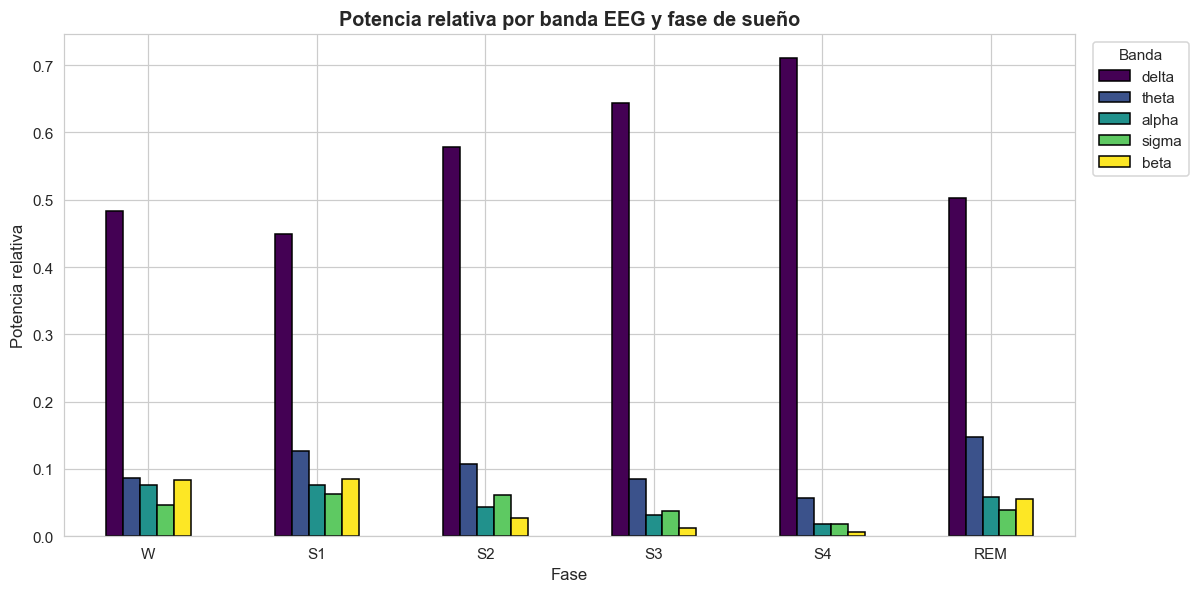

Figura guardada en D:\Repos\RAHBFDP-2026\notebooks\..\data\features_fases\perfil_bandas_por_fase.png


In [6]:
# Potencia relativa media por banda y fase (promedio entre canales y pacientes)
bandas_rel = [f'pot_{b}_rel' for b in EEG_BANDS]
perfil = dataset.groupby('stage')[bandas_rel].mean().reindex(CLASES_RK)
perfil.columns = [c.replace('pot_', '').replace('_rel', '') for c in perfil.columns]
print('Potencia relativa media por fase:')
print(perfil.round(3).to_string())

fig, ax = plt.subplots(figsize=(11, 5.5))
perfil.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black')
ax.set_title('Potencia relativa por banda EEG y fase de sueño',
             fontweight='bold')
ax.set_ylabel('Potencia relativa'); ax.set_xlabel('Fase')
ax.legend(title='Banda', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FEATURES_DIR / 'perfil_bandas_por_fase.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada en {FEATURES_DIR / "perfil_bandas_por_fase.png"}')

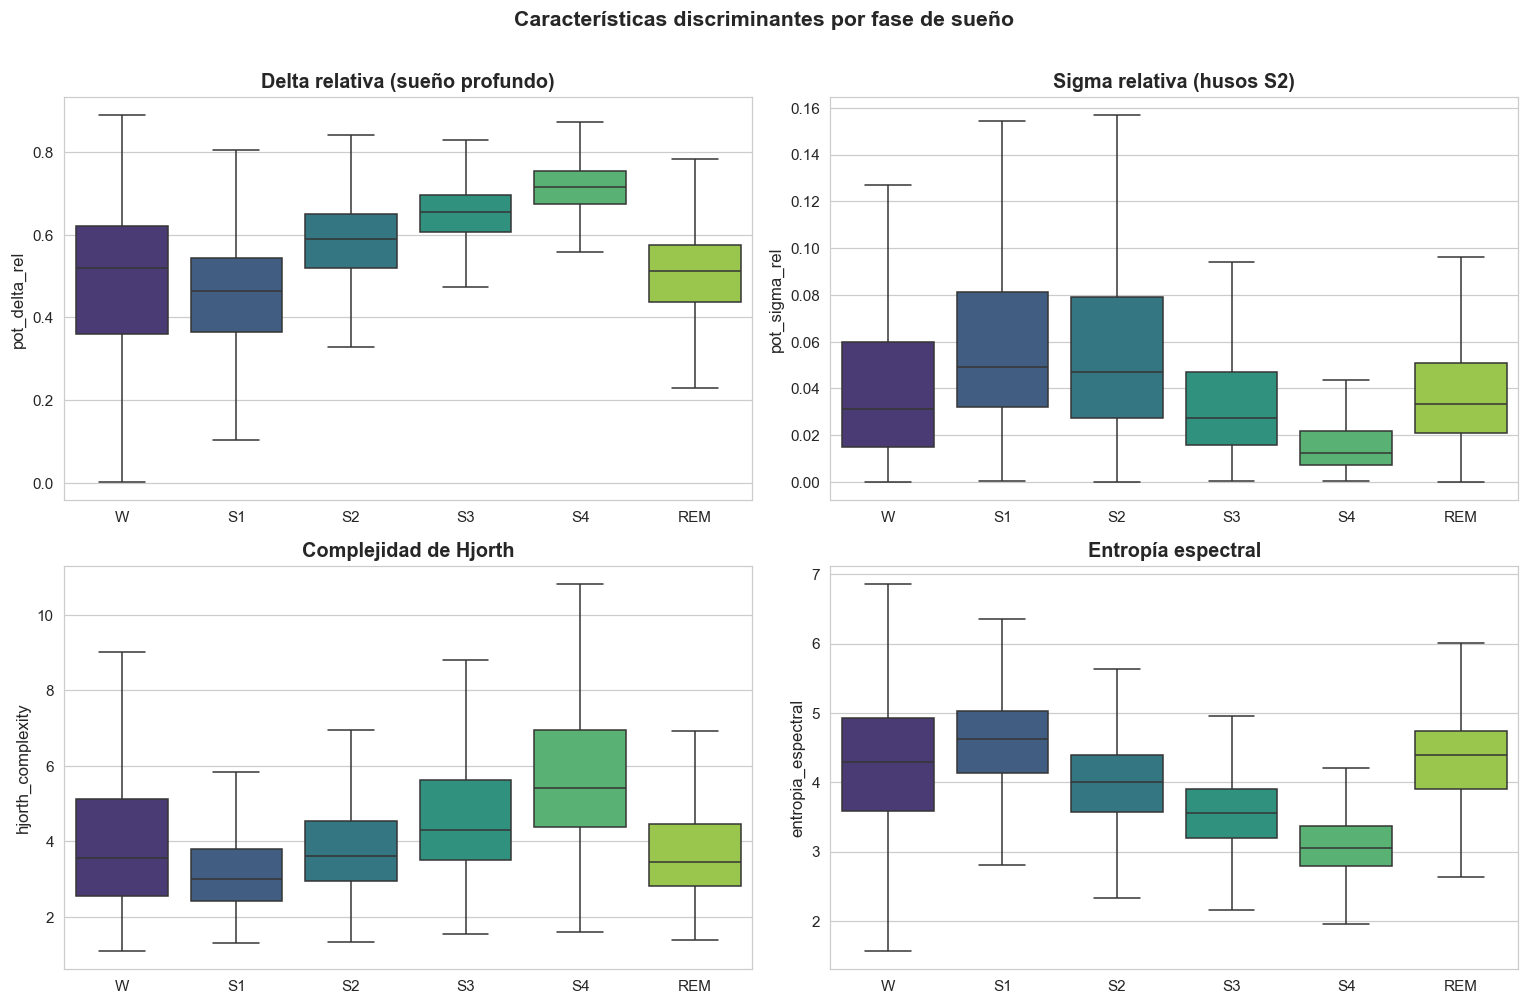

In [7]:
# Boxplots de características clave por fase
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
caracteristicas_clave = [
    ('pot_delta_rel', 'Delta relativa (sueño profundo)'),
    ('pot_sigma_rel', 'Sigma relativa (husos S2)'),
    ('hjorth_complexity', 'Complejidad de Hjorth'),
    ('entropia_espectral', 'Entropía espectral'),
]
for ax, (col, titulo) in zip(axes.flat, caracteristicas_clave):
    if col in dataset.columns:
        sns.boxplot(data=dataset, x='stage', y=col, order=CLASES_RK,
                    palette='viridis', ax=ax, showfliers=False)
        ax.set_title(titulo, fontweight='bold')
        ax.set_xlabel('')
plt.suptitle('Características discriminantes por fase de sueño',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FEATURES_DIR / 'caracteristicas_por_fase.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Exportación

Guardamos el dataset de características etiquetadas por fase, listo para el
notebook de modelado con validación por paciente.

In [8]:
ruta = FEATURES_DIR / 'caracteristicas_fases_30s.csv'
dataset.to_csv(ruta, index=False)

# Metadata
meta = pd.DataFrame([
    ('patient', 'Identificador del paciente (de qué EDF proviene)'),
    ('channel', 'Canal EEG (derivación bipolar 10-20)'),
    ('epoch_idx', 'Índice de la época dentro del hipnograma'),
    ('onset_s', 'Inicio de la época en segundos desde la 1ª época'),
    ('stage', 'ETIQUETA: fase de sueño R&K {W,S1,S2,S3,S4,REM}'),
], columns=['columna', 'descripcion'])
meta.to_csv(FEATURES_DIR / 'metadata_fases.csv', index=False)

print(f'✅ Dataset guardado: {ruta}')
print(f'   {dataset.shape[0]:,} filas × {dataset.shape[1]} columnas')
print(f'\nArchivos en {FEATURES_DIR}:')
for f in sorted(FEATURES_DIR.glob('*')):
    print(f'  {f.name:<40} {f.stat().st_size/1024:>8.1f} KB')

✅ Dataset guardado: D:\Repos\RAHBFDP-2026\notebooks\..\data\features_fases\caracteristicas_fases_30s.csv
   204,978 filas × 37 columnas

Archivos en D:\Repos\RAHBFDP-2026\notebooks\..\data\features_fases:
  caracteristicas_fases_30s.csv            121513.9 KB
  caracteristicas_por_fase.png                 92.2 KB
  metadata_fases.csv                            0.3 KB
  perfil_bandas_por_fase.png                   41.8 KB


## 8. Resumen y siguiente paso

### Lo que produjo este notebook

- Un dataset `(características, stage)` donde **cada fila es una época de
  30 s** correctamente etiquetada con su fase de sueño real.
- Resampleo automático a 256 Hz (importante: rbd8 estaba a 512 Hz).
- Banda **sigma** añadida para capturar husos del sueño (clave para S2).
- Verificación fisiológica de que las características separan las fases.

### Limitaciones a tener presentes

- **Desbalance fisiológico fuerte:** S2 suele dominar y S1 es minoritaria.
  El notebook de modelado deberá usar `class_weight`, métricas macro y
  Cohen's Kappa.
- **Pocos pacientes:** con 2 EDF de ejemplo, la validación por paciente es
  muy limitada. El pipeline escala a más pacientes añadiendo sus .txt/.edf.

### Siguiente notebook

El **notebook de modelado** tomará `caracteristicas_fases_30s.csv` y
entrenará Random Forest, XGBoost y SVM con:

- **Validación por paciente** (`StratifiedGroupKFold`) — sin fuga.
- Métricas apropiadas: accuracy, macro-F1, **Cohen's Kappa**, recall por
  fase, matriz de confusión.
- Análisis de qué fases son más difíciles de distinguir (típicamente
  S1↔REM y S3↔S4).

In [12]:
# Qué canales tiene cada paciente (esperamos 2 por paciente con MAX_CANALES=2)
canales_por_paciente = dataset.groupby('patient')['channel'].unique().apply(list)
print('Pacientes con sus canales:')
for p, chs in canales_por_paciente.items():
    print(f'  {p}: {chs}')

# Cuántos canales únicos hay en total y su frecuencia
print(f'\nCanales únicos en todo el dataset: {dataset["channel"].nunique()}')
print(dataset['channel'].value_counts())

Pacientes con sus canales:
  brux2: ['Fp2-F4', 'F4-C4']
  ins1: ['Fp2-F4', 'F4-C4']
  ins2: ['Fp2-F4', 'F4-C4']
  ins3: ['Fp2-F4', 'F4-C4']
  ins4: ['Fp2-F4', 'F4-C4']
  ins5: ['Fp2-F4', 'F4-C4']
  ins6: ['Fp2-F4', 'F4-C4']
  ins7: ['Fp2-F4', 'F4-C4']
  ins8: ['Fp2-F4', 'F4-C4']
  ins9: ['Fp2-F4', 'F4-C4']
  n1: ['F2-F4', 'F4-C4']
  n10: ['Fp2-F4', 'F4-C4']
  n11: ['Fp2-F4', 'F4-C4']
  n12: ['C3-A2', 'C4-A1']
  n2: ['Fp2-F4', 'F4-C4']
  n3: ['Fp2-F4', 'F4-C4']
  n4: ['Fp2-F4', 'F4-C4']
  n5: ['Fp2-F4', 'F4-C4']
  n6: ['C3-A2', 'O2-A1']
  n7: ['C3-A2', 'O2-A1']
  n8: ['C3-A2', 'C4-P4']
  n9: ['C3-A2', 'O2-A1']
  narco1: ['Fp2-F4', 'F4-C4']
  narco3: ['Fp2-F4', 'F4-C4']
  narco4: ['Fp2-F4', 'F4-C4']
  narco5: ['Fp2-F4', 'F4-C4']
  nfle1: ['Fp2-F4', 'F4-C4']
  nfle10: ['FP2-F4', 'F4-C4']
  nfle11: ['FP2-F4', 'F4-C4']
  nfle12: ['Fp2-F4', 'F4-C4']
  nfle13: ['Fp2-F4', 'F4-C4']
  nfle14: ['Fp2-F4', 'F4-C4']
  nfle15: ['Fp2-F4', 'F4-C4']
  nfle16: ['Fp2-F4', 'F4-C4']
  nfle17: ['Fp2-F4', 'F4